In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv(r"C:\Users\hp\Downloads\datasets\airlines_flights_data.csv")
df

,index,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955
...,...,...,...,...,...,...,...,...,...,...,...,...
300148,300148,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265
300149,300149,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105
300150,300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099
300151,300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585


In [3]:
df.isnull().sum()

index               0
airline             0
flight              0
source_city         0
departure_time      0
stops               0
arrival_time        0
destination_city    0
class               0
duration            0
days_left           0
price               0
dtype: int64

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   index             300153 non-null  int64  
 1   airline           300153 non-null  object 
 2   flight            300153 non-null  object 
 3   source_city       300153 non-null  object 
 4   departure_time    300153 non-null  object 
 5   stops             300153 non-null  object 
 6   arrival_time      300153 non-null  object 
 7   destination_city  300153 non-null  object 
 8   class             300153 non-null  object 
 9   duration          300153 non-null  float64
 10  days_left         300153 non-null  int64  
 11  price             300153 non-null  int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 27.5+ MB


In [7]:
df.drop(columns=['index'], inplace=True)

In [8]:
df.describe()

,duration,days_left,price
count,300153.000000,300153.000000,300153.000000
mean,12.221021,26.004751,20889.660523
std,7.191997,13.561004,22697.767366
min,0.830000,1.000000,1105.000000
25%,6.830000,15.000000,4783.000000
50%,11.250000,26.000000,7425.000000
75%,16.170000,38.000000,42521.000000
max,49.830000,49.000000,123071.000000


In [9]:
df["airline"].value_counts()

airline
Vistara      127859
Air_India     80892
Indigo        43120
GO_FIRST      23173
AirAsia       16098
SpiceJet       9011
Name: count, dtype: int64

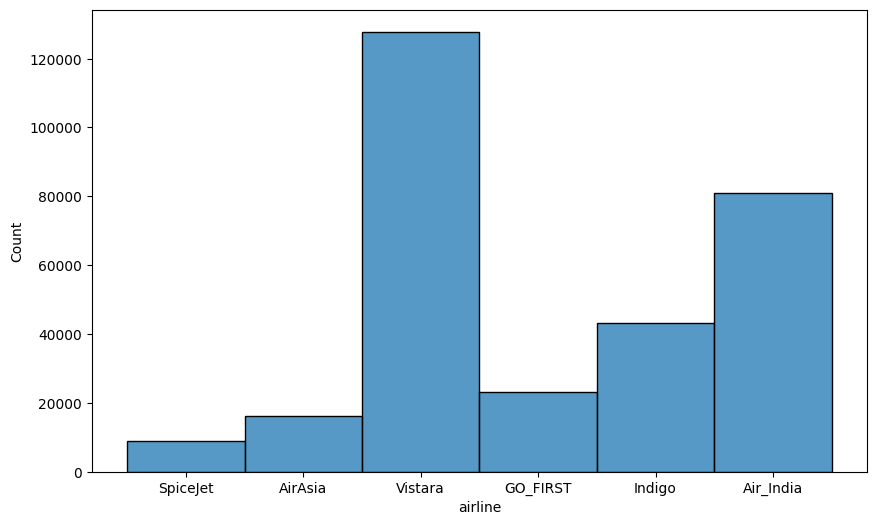

In [10]:
plt.figure(figsize=(10,6))
sns.histplot(df["airline"])
plt.show()

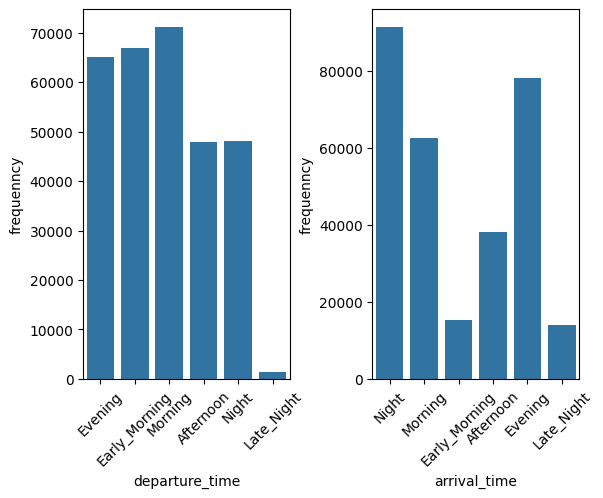

In [11]:
plt.subplot(1,2,1)
sns.countplot(x='departure_time', data=df)
plt.xlabel('departure_time')
plt.ylabel('frequenncy')
plt.xticks(rotation=45)

plt.subplot(1,2,2)
sns.countplot(x='arrival_time', data=df)
plt.xlabel('arrival_time')
plt.ylabel('frequenncy')
plt.xticks(rotation=45)
plt.subplots_adjust(wspace=0.4)

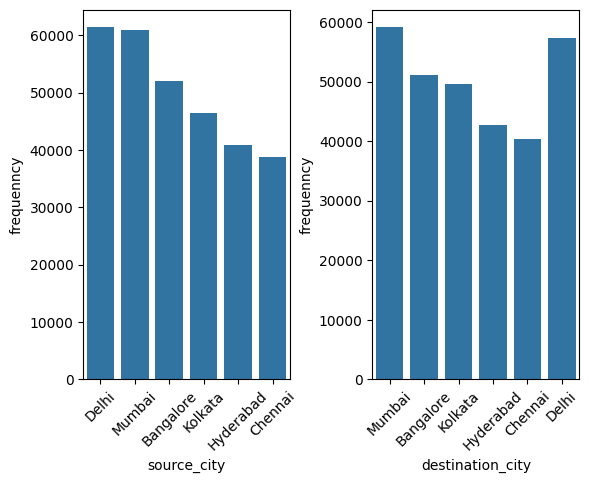

In [12]:
plt.subplot(1,2,1)
sns.countplot(x='source_city', data=df)
plt.xlabel('source_city')
plt.ylabel('frequenncy')
plt.xticks(rotation=45)

plt.subplot(1,2,2)
sns.countplot(x='destination_city', data=df)
plt.xlabel('destination_city')
plt.ylabel('frequenncy')
plt.xticks(rotation=45)
plt.subplots_adjust(wspace=0.4)

In [13]:
df.groupby('airline')['price'].median().sort_values(ascending=False)

airline
Vistara      15543.0
Air_India    11520.0
SpiceJet      5654.0
GO_FIRST      5336.0
Indigo        4453.0
AirAsia       3276.0
Name: price, dtype: float64

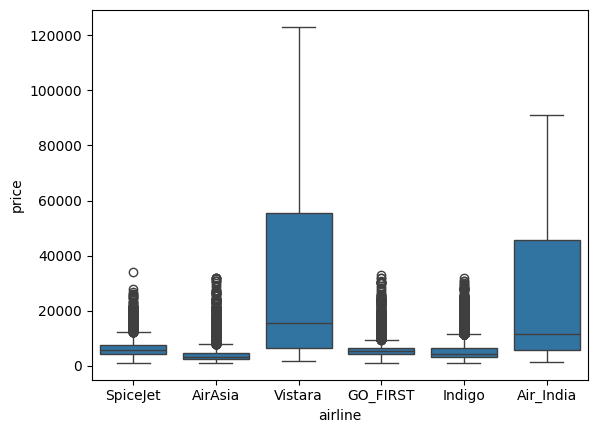

In [14]:
sns.boxplot(x='airline',y='price', data=df)
plt.xlabel('airline')
plt.ylabel('price')
plt.show()

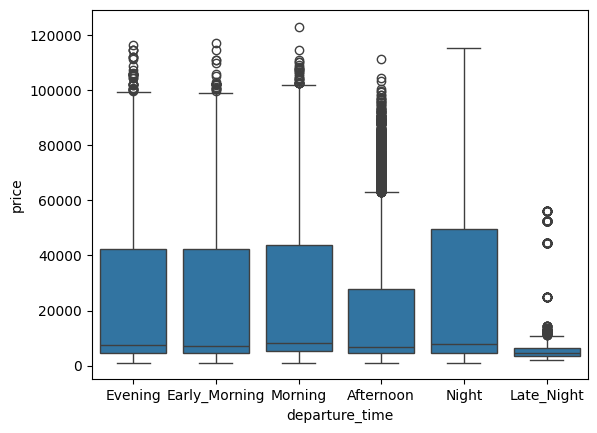

In [15]:
sns.boxplot(x='departure_time',y='price', data=df)
plt.xlabel('departure_time')
plt.ylabel('price')
plt.show()

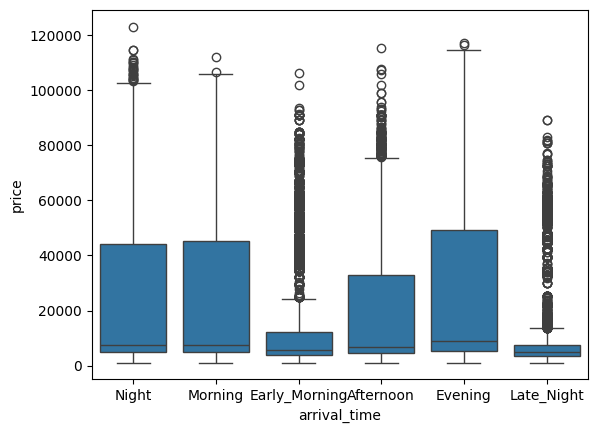

In [16]:
sns.boxplot(x='arrival_time',y='price', data=df)
plt.xlabel('arrival_time')
plt.ylabel('price')
plt.show()

In [17]:
pivot= df.pivot_table(index='source_city', columns="destination_city", values="price", aggfunc="mean")
pivot

destination_city,Bangalore,Chennai,Delhi,Hyderabad,Kolkata,Mumbai
source_city,,,,,,
Bangalore,NaN,23321.850078,17723.313972,21226.121192,23500.061229,23128.618672
Chennai,25081.850454,NaN,18981.863948,21591.345404,22669.932407,22765.849647
Delhi,17880.216315,19369.881354,NaN,17347.288379,20566.409418,19355.829812
Hyderabad,21347.177998,21848.065989,17243.945685,NaN,20823.893201,20080.865759
Kolkata,22744.808428,23660.361040,19422.354559,21500.011397,NaN,22078.883579
Mumbai,23147.873807,22781.899112,18725.320008,21004.046705,22379.146723,NaN


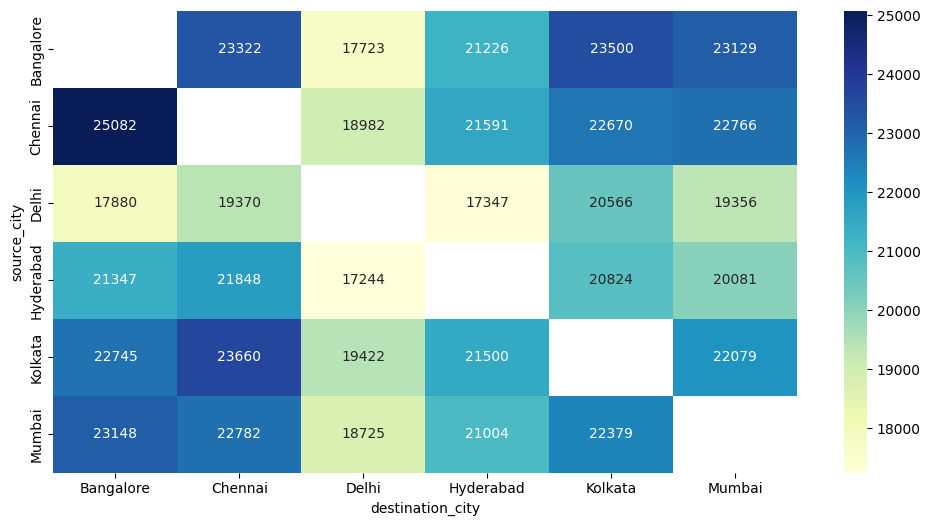

In [18]:
plt.figure(figsize=(12,6))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="YlGnBu")
plt.show()

In [19]:
df_sort=df[df['days_left']<=2]
df_sort

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955
...,...,...,...,...,...,...,...,...,...,...,...
298090,Vistara,UK-838,Chennai,Night,one,Evening,Hyderabad,Business,22.83,2,66129
298091,Vistara,UK-834,Chennai,Evening,one,Morning,Hyderabad,Business,16.50,2,82784
298092,Vistara,UK-834,Chennai,Evening,one,Afternoon,Hyderabad,Business,19.42,2,82784
298093,Vistara,UK-834,Chennai,Evening,one,Evening,Hyderabad,Business,23.83,2,82784


In [20]:
df_sort.groupby('days_left')['price'].median()

days_left
1    15163.0
2    18017.5
Name: price, dtype: float64

In [21]:
df_sort.groupby('class')['price'].mean()

class
Business    61205.717703
Economy     14226.176361
Name: price, dtype: float64

In [22]:
df_sort.groupby('class')['duration'].median()

class
Business    15.75
Economy     11.50
Name: duration, dtype: float64

In [23]:
df_sort.groupby('stops')['price'].median()

stops
one            17715.0
two_or_more    18602.0
zero            8055.0
Name: price, dtype: float64

In [24]:
df['days_group']=pd.cut(df['days_left'],bins=[0,10,20,30,40,50,100], labels=['0-10','11-20','21-30','31-40','41-50','51+'])
df[['days_left','days_group']]

,days_left,days_group
0,1,0-10
1,1,0-10
2,1,0-10
3,1,0-10
4,1,0-10
...,...,...
300148,49,41-50
300149,49,41-50
300150,49,41-50
300151,49,41-50


In [25]:
df.groupby('days_group')['price'].mean()

C:\Users\hp\AppData\Local\Temp\ipykernel_7976\3530339946.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('days_group')['price'].mean()


days_group
0-10     26082.751717
11-20    21260.475515
21-30    19625.787849
31-40    19393.765657
41-50    19108.742210
51+               NaN
Name: price, dtype: float64

C:\Users\hp\AppData\Local\Temp\ipykernel_7976\745393974.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sns.barplot(x='days_group',y='price',data=df.groupby('days_group')['price'].mean().reset_index())


<Axes: xlabel='days_group', ylabel='price'>

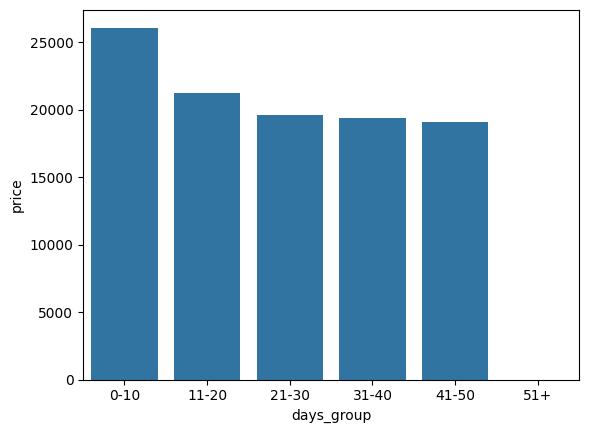

In [26]:
sns.barplot(x='days_group',y='price',data=df.groupby('days_group')['price'].mean().reset_index())

In [27]:
df['class'].value_counts()

class
Economy     206666
Business     93487
Name: count, dtype: int64

In [28]:
new=df.sort_values(by='price', ascending=False).head(3)
new[['airline','source_city','destination_city','price']]

,airline,source_city,destination_city,price
261377,Vistara,Kolkata,Delhi,123071
216096,Vistara,Delhi,Kolkata,117307
215859,Vistara,Delhi,Kolkata,116562


In [29]:
df['price']

0          5953
1          5953
2          5956
3          5955
4          5955
          ...  
300148    69265
300149    77105
300150    79099
300151    81585
300152    81585
Name: price, Length: 300153, dtype: int64

In [30]:
Q1=df['price'].quantile(0.25)
Q3=df['price'].quantile(0.75)
IQR=Q3-Q1
lower=Q1-1.5*IQR
upper=Q3+1.5*IQR
outliers=df[(df['price']<lower)|(df['price']>upper)]
outliers

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price,days_group
215858,Vistara,UK-809,Delhi,Evening,two_or_more,Evening,Kolkata,Business,21.08,1,114434,0-10
215859,Vistara,UK-809,Delhi,Evening,two_or_more,Evening,Kolkata,Business,21.08,1,116562,0-10
216025,Vistara,UK-817,Delhi,Evening,two_or_more,Morning,Kolkata,Business,17.58,4,100395,0-10
216094,Vistara,UK-995,Delhi,Morning,one,Evening,Kolkata,Business,6.50,5,99129,0-10
216095,Vistara,UK-963,Delhi,Morning,one,Evening,Kolkata,Business,8.00,5,101369,0-10
...,...,...,...,...,...,...,...,...,...,...,...,...
293474,Vistara,UK-836,Chennai,Morning,one,Night,Bangalore,Business,9.67,3,107597,0-10
296001,Vistara,UK-838,Chennai,Night,one,Morning,Kolkata,Business,11.50,3,102832,0-10
296081,Vistara,UK-832,Chennai,Early_Morning,one,Night,Kolkata,Business,15.83,5,102384,0-10
296170,Vistara,UK-838,Chennai,Night,one,Morning,Kolkata,Business,11.50,7,104624,0-10


In [33]:
df=df[(df['price']>lower)&(df['price']<upper)]
df

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price,days_group
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953,0-10
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953,0-10
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956,0-10
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955,0-10
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955,0-10
...,...,...,...,...,...,...,...,...,...,...,...,...
300148,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265,41-50
300149,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105,41-50
300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099,41-50
300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585,41-50


In [34]:
df['price'].mean()

np.float64(20855.326673999265)

In [35]:
df['price'].median()

np.float64(7425.0)

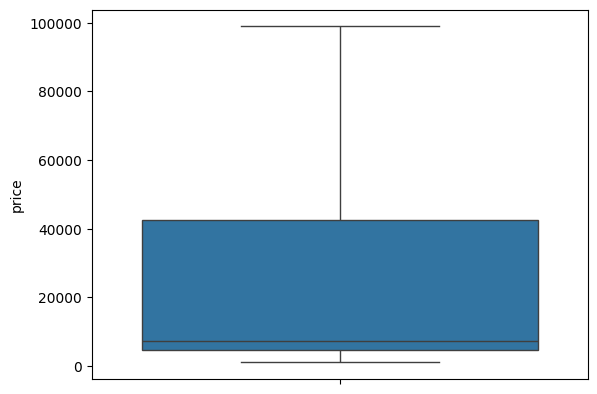

In [41]:
sns.boxplot(df['price'])
plt.show()

In [42]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn import metrics

In [59]:
x=df[['days_left']]
y=df['price']

In [60]:
X_train, X_test, y_train, y_test= train_test_split(x,y,test_size=0.2, random_state=42)


In [61]:
reg=LinearRegression()
reg.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


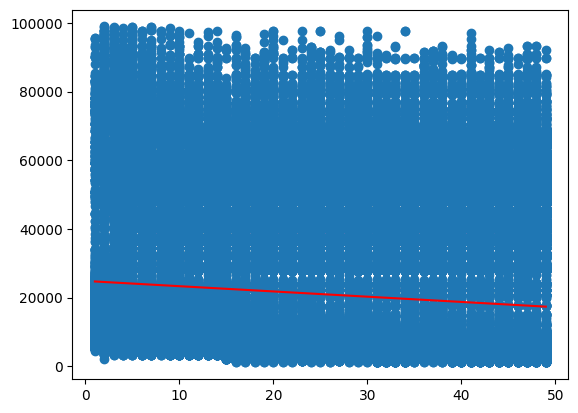

In [62]:
plt.scatter(x,y)
yhat=reg.coef_*x+reg.intercept_
fig=plt.plot(x,yhat,c='red')
plt.show()

In [65]:
df.to_csv("airlines_flight_data.csv", index=False)